Using CUDA (NVIDIA).
Total Classes: 60
Class Names: ['adelholzener_alpenquelle_classic_075', 'adelholzener_alpenquelle_naturell_075', 'adelholzener_classic_bio_apfelschorle_02', 'adelholzener_classic_naturell_02', 'adelholzener_gourmet_mineralwasser_02', 'apple_braeburn_bundle', 'apple_golden_delicious', 'apple_granny_smith', 'apple_red_boskoop', 'augustiner_lagerbraeu_hell_05', 'augustiner_weissbier_05', 'avocado', 'banana_bundle', 'banana_single', 'cafe_wunderbar_espresso', 'caona_cocoa', 'carrot', 'clementine', 'clementine_single', 'coca_cola_05', 'coca_cola_light_05', 'cocoba_cocoa', 'corn_salad', 'corny_nussvoll', 'corny_nussvoll_single', 'corny_schoko_banane', 'corny_schoko_banane_single', 'cucumber', 'douwe_egberts_professional_ground_coffee', 'dr_oetker_vitalis_knuspermuesli_klassisch', 'ethiquable_gruener_tee_ceylon', 'franken_tafelreiniger', 'gepa_bio_caffe_crema', 'gepa_bio_und_fair_fencheltee', 'gepa_bio_und_fair_kamillentee', 'gepa_bio_und_fair_kraeuterteemischung', 'gepa_

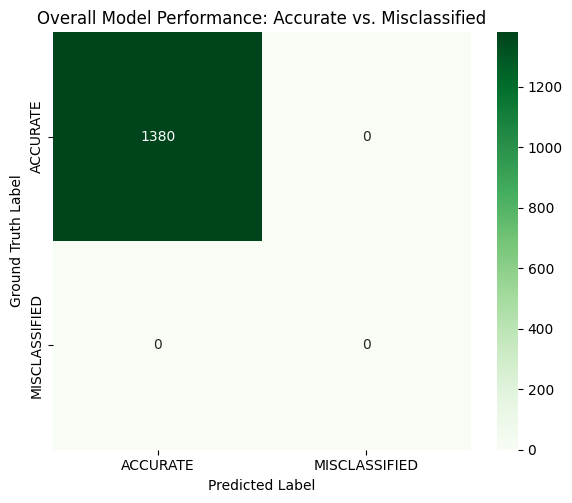

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# --- DEVICE SETUP ---
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple Metal (MPS).")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA (NVIDIA).")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU.")

# --- HYPERPARAMETERS & PATHS ---
RESNET_MODEL_SAVE_PATH = "best_resnet_model.pth"
TRAIN_DIR = './training_data'
VAL_DIR = './validation_data'
TEST_DIR = './testing_data' # Added for your final test evaluation

# --- DATA PREPROCESSING ---
data_transforms = transforms.Compose([
    transforms.Resize((448, 448)), # High-res for label detail
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def train_model(epochs, batch_size, lr):
    # Load Datasets
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=data_transforms)
    val_dataset = datasets.ImageFolder(VAL_DIR, transform=data_transforms)

    print(f"Total Classes: {len(train_dataset.classes)}")
    print(f"Class Names: {train_dataset.classes}")
    print(f"Mapping (Folder -> Index): {train_dataset.class_to_idx}")

    num_classes = len(train_dataset.classes)
    print(f"Detected {num_classes} classes.")

    # DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True, # Randomizes image order
        num_workers=4, # Uses 4 CPU cores to "pre-fetch" images so the GPU never waits
        pin_memory=True, # Locks data into a "fast-lane" in RAM for quicker GPU transfer
        persistent_workers=True # Workers stay
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False, # No need to shuffle
        num_workers=4, # Speeds up the validation check so training resumes faster
        persistent_workers=True # Workers stay
    )

    # --- MODEL SETUP ---
    model = models.resnet18(weights='IMAGENET1K_V1')
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(DEVICE)

    if os.path.isfile(RESNET_MODEL_SAVE_PATH):
        print(f"Loading existing weights from {RESNET_MODEL_SAVE_PATH}")
        model.load_state_dict(torch.load(RESNET_MODEL_SAVE_PATH, map_location=DEVICE))

    # --- OPTIMIZER & SCHEDULER ---
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3)

    # --- TRAINING LOOP ---
    print("\nStarting Training...")

    # Tracking metrics
    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        # Gradient Accumulation
        accumulation_steps = 4
        optimizer.zero_grad()

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels) / accumulation_steps
            loss.backward()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                optimizer.step()
                optimizer.zero_grad()

            running_loss += loss.item() * accumulation_steps

        avg_train_loss = running_loss / len(train_loader)
        history["train_loss"].append(avg_train_loss)

        # --- VALIDATION ---
        model.eval()
        v_running_loss = 0.0
        with torch.no_grad():
            for v_inputs, v_labels in val_loader:
                v_inputs, v_labels = v_inputs.to(DEVICE), v_labels.to(DEVICE)
                v_outputs = model(v_inputs)
                v_loss = criterion(v_outputs, v_labels)
                v_running_loss += v_loss.item()

        avg_val_loss = v_running_loss / len(val_loader)
        history["val_loss"].append(avg_val_loss)

        scheduler.step(avg_val_loss)

        # Save Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), RESNET_MODEL_SAVE_PATH)
            save_msg = "--> Best Model Saved!"
        else:
            save_msg = ""

        # Corrected print statement with your original parameters restored
        print(f"Epoch [{epoch+1}/{epochs}] | LR: {optimizer.param_groups[0]['lr']} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} |  {save_msg}")
    return history

# --- Evaluation Report ---
def run_final_evaluation(model, test_loader):
    print("\n--- FINAL TEST SET PERFORMANCE (OVERALL MATCH) ---")
    model.eval()
    all_predictions = []
    all_labels = []

    # Collect all predictions and true labels
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Print detailed metrics for F1, Precision, Recall
    print(classification_report(all_labels, all_predictions, target_names=test_loader.dataset.classes))

    # Calculate 4-Section Aggregated Statistics
    cm_full = confusion_matrix(all_labels, all_predictions)

    total_samples = cm_full.sum()
    accurate_count = np.trace(cm_full)        # Total correctly predicted (Diagonal sum)
    misclassified_count = total_samples - accurate_count  # Total errors

    # Create the 2x2 summary matrix
    # We place both on the diagonal to show "Correctness" vs "Error"
    summary_matrix = [
        [accurate_count, 0],
        [0, misclassified_count]
    ]

    # Plot the 2x2 Summary Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(summary_matrix,
                annot=True,
                fmt='d',
                cmap='Greens',
                xticklabels=['ACCURATE', 'MISCLASSIFIED'],
                yticklabels=['ACCURATE', 'MISCLASSIFIED'],
                cbar=True,
                square=True)

    plt.title('Overall Model Performance: Accurate vs. Misclassified')
    plt.ylabel('Ground Truth Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------------------------------------------------------


# Run training
# Run original training
train_history = train_model(epochs=30, batch_size=4, lr=1e-04)

# Setup model to load best weights for final test evaluation
# Using ImageFolder on TEST_DIR to get class count and loader
test_dataset = datasets.ImageFolder(TEST_DIR, transform=data_transforms)
num_classes = len(test_dataset.classes)

final_model = models.resnet18()
final_model.fc = nn.Linear(final_model.fc.in_features, num_classes)
final_model.load_state_dict(torch.load(RESNET_MODEL_SAVE_PATH, map_location=DEVICE))
final_model.to(DEVICE)

# Create final test loader and run evaluation
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)
run_final_evaluation(final_model, test_loader)

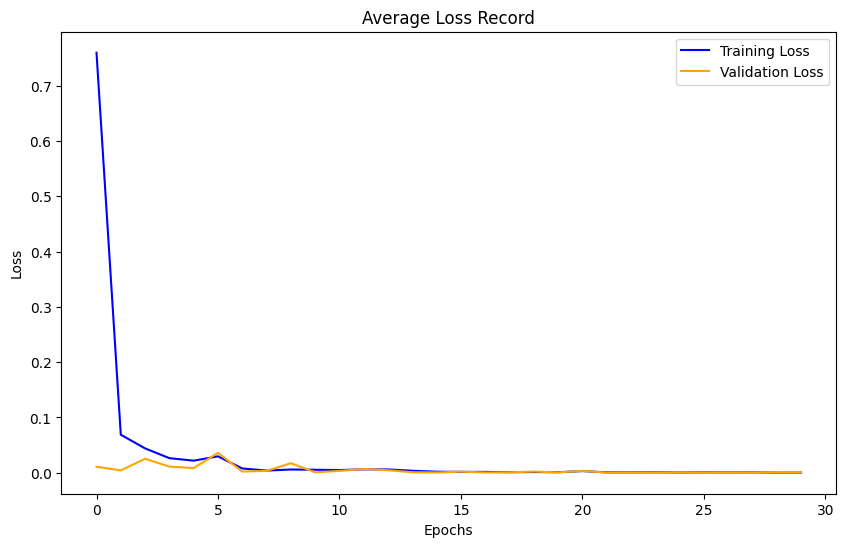

In [2]:
plt.figure(figsize=(10, 6))

# Plotting Train and Validation Loss
plt.plot(train_history['train_loss'], label='Training Loss', color='blue')
plt.plot(train_history['val_loss'], label='Validation Loss', color='orange')

plt.title('Average Loss Record')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig('loss_curves.png')
plt.show()